<a href="https://colab.research.google.com/github/jegillis323/MAT-422/blob/main/MAT422_Section_1_2_Linear_Algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 1.2: Linear Algebra Concepts in Python

**Topics:** linear spaces, orthogonality, Gram-Schmidt process, eigenvalues and eigenvectors

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.2.1 Linear Spaces

A linear space is closed under vector addition and scalar multiplication. In this example, vectors in R3 stay in R3 after we add them or multiply them by scalars. We also show a span calculation: a linear combination of two vectors is still in the same space.

In [17]:
u = np.array([2, -1, 3], dtype=float)
v = np.array([-4, 5, 1], dtype=float)
c = 2.5

w = np.array([6, -5, -4], dtype=float)
x = np.array([2, 8, 6], dtype=float)
d = 5

print("u =", u)
print("v =", v)
print("u + v =", u + v)
print("c * u =", c * u)
print("linear combination 3u - 2v =", 3*u - 2*v)
print("zero vector =", np.zeros_like(u))
print("additive inverse check u + (-u) =", u + (-u))
print("w =", w)
print("x =", x)
print("w + x =", w + x)
print("linear combination 2w + 3x =", 2*w + 3*x)



u = [ 2. -1.  3.]
v = [-4.  5.  1.]
u + v = [-2.  4.  4.]
c * u = [ 5.  -2.5  7.5]
linear combination 3u - 2v = [ 14. -13.   7.]
zero vector = [0. 0. 0.]
additive inverse check u + (-u) = [0. 0. 0.]
w = [ 6. -5. -4.]
x = [2. 8. 6.]
w + x = [8. 3. 2.]
linear combination 2w + 3x = [18. 14. 10.]


My Explanation: We can see that when creating any kind of linear combination of the vectors u and v together, we stay in R3. Adding or subtracting vectors together or scaling a vector by a constant produces another vector that is in R3, showing the vector space is closed under these operations.

A useful non-example is the set of vectors in R2 whose first coordinate is exactly 1. It is not a vector space because multiplying by most scalars leaves the set.

In [9]:
w = np.array([1, 3], dtype=float)
scaled_w = 2 * w
print("w =", w)
print("2w =", scaled_w)
print("Is 2w still in the set first coordinate = 1?", np.isclose(scaled_w[0], 1))

v = np.array([5,10], dtype=float)
scaled_v = (1/3) * v
print("v =", v)
print("1/3v =", scaled_v)
print("Is 1/3v still in the set first coordinate = 5?", np.isclose(scaled_v[0], 5))

w = [1. 3.]
2w = [2. 6.]
Is 2w still in the set first coordinate = 1? False
v = [ 5. 10.]
1/3v = [1.6667 3.3333]
Is 1/3v still in the set first coordinate = 5? False


My Explanation: Both in the given example and the additional example I provided show that when scaling a vector, it changes the values, thus not keeping it in the set of vectors in R2 that have the first coordinate of 1 or 5. Only multiplying by the scalar 1 would keep it unchanged and in the set.

## 1.2.2 Orthogonality

Two vectors are orthogonal when their dot product is zero. Geometrically, this means the angle between them is 90 degrees. The projection of one vector onto an orthogonal vector has zero length.

a dot b = 0.0
angle in degrees = 90.0
projection of a onto b = [ 0. -0.]
c dot d = 0.0
angle in degrees = 90.0
projection of c onto d = [-0.  0.]


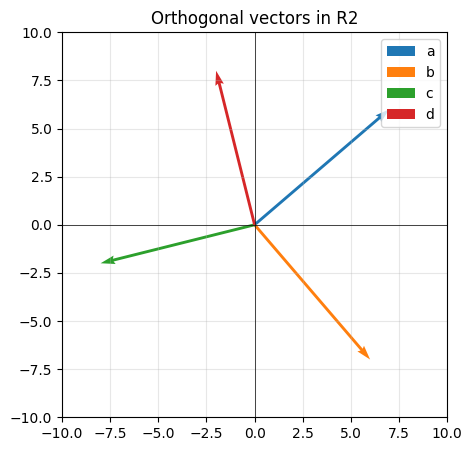

In [13]:
a = np.array([7, 6], dtype=float)
b = np.array([6, -7], dtype=float)
c = np.array([-8, -2], dtype=float)
d = np.array([-2, 8], dtype=float)

dot_ab = np.dot(a, b)
angle_ab = np.degrees(np.arccos(dot_ab / (np.linalg.norm(a) * np.linalg.norm(b))))
projection_of_a_on_b = (np.dot(a, b) / np.dot(b, b)) * b

dot_cd = np.dot(c, d)
angle_cd = np.degrees(np.arccos(dot_cd / (np.linalg.norm(c) * np.linalg.norm(d))))
projection_of_c_on_d = (np.dot(c, d) / np.dot(d, d)) * d

print("a dot b =", dot_ab)
print("angle in degrees =", angle_ab)
print("projection of a onto b =", projection_of_a_on_b)

print("c dot d =", dot_cd)
print("angle in degrees =", angle_cd)
print("projection of c onto d =", projection_of_c_on_d)

plt.figure(figsize=(5, 5))
plt.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1, color="tab:blue", label="a")
plt.quiver(0, 0, b[0], b[1], angles="xy", scale_units="xy", scale=1, color="tab:orange", label="b")
plt.quiver(0, 0, c[0], c[1], angles="xy", scale_units="xy", scale=1, color="tab:green", label="c")
plt.quiver(0, 0, d[0], d[1], angles="xy", scale_units="xy", scale=1, color="tab:red", label="d")
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.title("Orthogonal vectors in R2")
plt.show()

My Explanation: In both examples, the dot products for the given vector pairs are zero, meaning that they are orthogonal. This can be seen in the graph as both pairs of the vectors make a 90 degree angle with each other. That means  the vectors are independent of one another. Because their projection of one vector on another is zero, neither vector has any component in the other. Thus, going in the direction of one will not go in the direction the other.

## 1.2.3 Gram-Schmidt Process

The Gram-Schmidt process converts a linearly independent set of vectors into an orthonormal basis for the same span. The loop below subtracts projections onto earlier basis vectors, then normalizes the remaining component.

In [14]:
def gram_schmidt(columns):
    basis = []
    for x in columns.T:
        y = x.astype(float).copy()
        for q in basis:
            y -= np.dot(q, y) * q
        norm_y = np.linalg.norm(y)
        if norm_y < 1e-12:
            raise ValueError("Input vectors are linearly dependent or nearly dependent.")
        basis.append(y / norm_y)
    return np.column_stack(basis)

A = np.array([
    [1, 1, 0],
    [1, 0, 1],
    [0, 1, 1],
], dtype=float)

B = np.array([
    [5, 2, 1],
    [6, 7, 9],
    [8, 3, 1],
], dtype=float)

Q = gram_schmidt(A)
print("Original column vectors A:")
print(A)
print("\nOrthonormal basis Q:")
print(Q)
print("\nQ.T @ Q should be the identity matrix:")
print(Q.T @ Q)
print("All close to identity?", np.allclose(Q.T @ Q, np.eye(3)))

R = gram_schmidt(B)
print("\n\nOriginal column vectors B:")
print(B)
print("\nOrthonormal basis R:")
print(R)
print("\nR.T @ R should be the identity matrix:")
print(R.T @ R)

Original column vectors A:
[[1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]]

Orthonormal basis Q:
[[ 0.7071  0.4082 -0.5774]
 [ 0.7071 -0.4082  0.5774]
 [ 0.      0.8165  0.5774]]

Q.T @ Q should be the identity matrix:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
All close to identity? True


Original column vectors B:
[[5. 2. 1.]
 [6. 7. 9.]
 [8. 3. 1.]]

Orthonormal basis R:
[[ 0.4472 -0.2617  0.8553]
 [ 0.5367  0.8435 -0.0225]
 [ 0.7155 -0.4691 -0.5177]]

R.T @ R should be the identity matrix:
[[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]


My Explanation: The Gram-Schmidt process takes three independent vectors and transforms them into an orthonormal basis of the space. The process subtracts the projection of the first vector from the second vector to make them orthogonal. This repeats the same for the third vector so three perpendicular vectors are left over. Then it is normalized so each vector has a length of one. That is why Q$^T$Q is equal to the identity matrix.

## 1.2.4 Eigenvalues and Eigenvectors

For a square matrix A, an eigenvector v keeps its direction when multiplied by A. Only its scale changes: `A v = lambda v`, where lambda is the eigenvalue.

In [20]:
M = np.array([
    [2, 1],
    [1, 2],
], dtype=float)

N = np.array([
    [5,7],
    [3,8],
], dtype=float)

eigenvaluesM, eigenvectorsM = np.linalg.eig(M)
print("Matrix M:")
print(M)
print("eigenvalues of M =", eigenvaluesM)
print("eigenvectors of M as columns:")
print(eigenvectorsM)

for i, lam in enumerate(eigenvaluesM):
    vec = eigenvectorsM[:, i]
    residual = M @ vec - lam * vec
    print(f"\nEigenpair {i+1}")
    print("lambda =", lam)
    print("v =", vec)
    print("M @ v =", M @ vec)
    print("lambda * v =", lam * vec)
    print("residual norm =", np.linalg.norm(residual))

eigenvaluesN, eigenvectorsN = np.linalg.eig(N)
print("\n\nMatrix N:")
print(N)
print("eigenvalues of N =", eigenvaluesN)
print("eigenvectors of N as columns:")
print(eigenvectorsN)

for i, lam in enumerate(eigenvaluesN):
    vec = eigenvectorsN[:, i]
    residual = N @ vec - lam * vec
    print(f"\nEigenpair {i+1}")
    print("lambda =", lam)
    print("v =", vec)
    print("N @ v =", N @ vec)
    print("lambda * v =", lam * vec)
    print("residual norm =", np.linalg.norm(residual))

Matrix M:
[[2. 1.]
 [1. 2.]]
eigenvalues of M = [3. 1.]
eigenvectors of M as columns:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Eigenpair 1
lambda = 3.0
v = [0.7071 0.7071]
M @ v = [2.1213 2.1213]
lambda * v = [2.1213 2.1213]
residual norm = 0.0

Eigenpair 2
lambda = 1.0
v = [-0.7071  0.7071]
M @ v = [-0.7071  0.7071]
lambda * v = [-0.7071  0.7071]
residual norm = 0.0


Matrix N:
[[5. 7.]
 [3. 8.]]
eigenvalues of N = [ 1.6782 11.3218]
eigenvectors of N as columns:
[[-0.9034 -0.7421]
 [ 0.4287 -0.6702]]

Eigenpair 1
lambda = 1.6781746195035225
v = [-0.9034  0.4287]
N @ v = [-1.5161  0.7195]
lambda * v = [-1.5161  0.7195]
residual norm = 0.0

Eigenpair 2
lambda = 11.321825380496477
v = [-0.7421 -0.6702]
N @ v = [-8.4024 -7.5884]
lambda * v = [-8.4024 -7.5884]
residual norm = 1.9860273225978185e-15


My Explanation: An eigenvector is a vector that does not change in direction when multiplied by a matrix and the eigenvalue that corresponds to this is the amount that the vector changes in size after it is multiplied. The residual values being basically zero show that the eigenvectors satisfy the equation Av = λv.